In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
print('ALL ASSETS IMPORTED')

ALL ASSETS IMPORTED


In [5]:
#loading the data
data  = pd.read_csv('creditcard.csv')
#data.head()

data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
#checking if the dataset is imbalanced
valid = data[data['Class'] == 0]
fraud = data[data['Class'] == 1]

outlierration = len(fraud) / float(len(valid))
print('Outlierration: {:.4f}'.format(outlierration))
print('percentage of outliers: {:.4f}%'.format(outlierration*100))

#printing the no of fraud and valid transactions
print('No of valid transactions: {}'.format(len(valid)))
print('No of fraud transactions: {}'.format(len(fraud)))

Outlierration: 0.0017
percentage of outliers: 0.1730%
No of valid transactions: 284315
No of fraud transactions: 492


In [9]:
#exploring the transaction amount
print('Transaction amount details:')
data.Amount.describe()

Transaction amount details:


count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [10]:
#details of  fraud transactions
print('Details of fraud transactions:')
fraud.Amount.describe()


Details of fraud transactions:


count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [11]:
#details of the valid transactions
print('Details of valid transactions: ')
valid.Amount.describe()

Details of valid transactions: 


count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

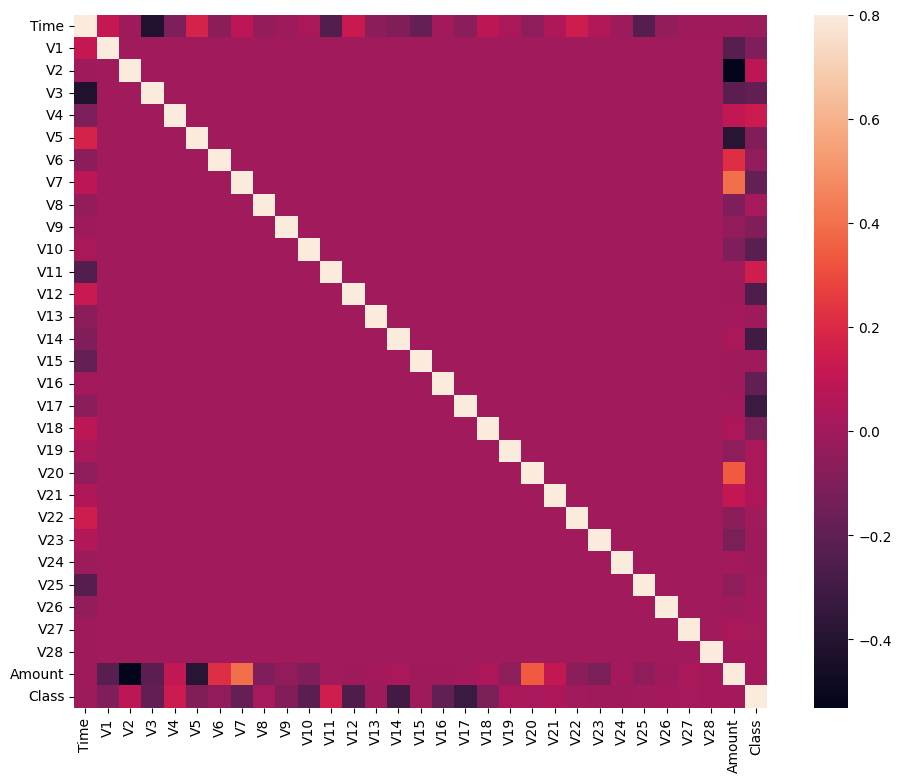

In [12]:
#plotting a corr map
cormat = data.corr()
fig = plt.figure(figsize=(12,9))
sns.heatmap(cormat, vmax=0.8, square=True)
plt.show()
#the correlation map shows that there is no significant correlation between the features and the class variable. This is because the data has been transformed using PCA (Principal Component Analysis) to protect the confidentiality of the data.

In [14]:
#preparing the data for modeling
x = data.drop('Class', axis=1)
y = data['Class']
print('Shape of x: {}'.format(x.shape))
print('Shape of y: {}'.format(y.shape))

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)
print('Training set shape: {}'.format(x_train.shape))
print('Testing set shape: {}'.format(x_test.shape))

Shape of x: (284807, 30)
Shape of y: (284807,)
Training set shape: (199364, 30)
Testing set shape: (85443, 30)


In [15]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier()

#fitting the model on training data
random_forest.fit(x_train, y_train)
print('Random Forest Classifier trained successfully.')

Random Forest Classifier trained successfully.


In [16]:
#predicting on test set
y_pred = random_forest.predict(x_test)
print('Predictions on test set completed.')


Predictions on test set completed.


Accuracy: 99.9579 %
Precision: 93.1034 %
F1 Score: 85.7143 %
Recall score: 79.4118 %
Matthews Correlation Coefficient: 0.8597


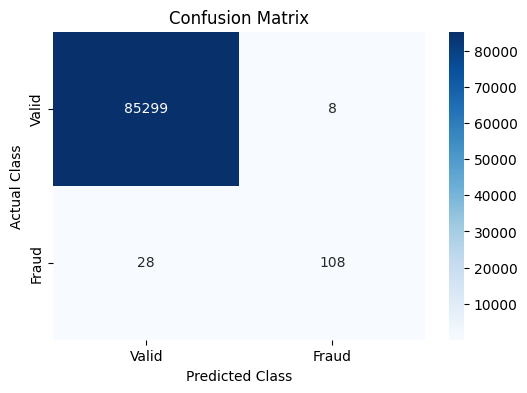

In [22]:
#evaluating the model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import matthews_corrcoef

#accuracy
accuracy_1 = accuracy_score(y_test, y_pred)
print('Accuracy: {:.4f} %'.format(accuracy_1* 100))

#precision 
precision_1 = precision_score(y_test, y_pred)
print('Precision: {:.4f} %'.format(precision_1 * 100))

#f1 score
f1_score_of_model = f1_score(y_test, y_pred)
print('F1 Score: {:.4f} %'.format(f1_score_of_model * 100))

#recall score
recall_score_oof_model = recall_score(y_test, y_pred)
print('Recall score: {:.4f} %'.format(recall_score_oof_model * 100))

#mathews correlation coefficient
mathew_perry = matthews_corrcoef(y_test, y_pred)
print('Matthews Correlation Coefficient: {:.4f}'.format(mathew_perry))


#confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Valid', 'Fraud'], yticklabels=['Valid', 'Fraud'])
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.title('Confusion Matrix')
plt.show()


